In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

KeyboardInterrupt: 

In [ ]:
df = pd.read_csv('HQ_Data_Clean_new.csv')

df= df.drop(columns=['subject_sp_id'])


In [ ]:
scaler = StandardScaler()
data = scaler.fit_transform(df)


In [ ]:
# Split into train and validation sets
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Convert to TensorFlow dataset
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_data)).batch(BATCH_SIZE).shuffle(1024)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_data)).batch(BATCH_SIZE)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.losses import BinaryCrossentropy
import keras.backend as K
from keras.saving import register_keras_serializable
from keras.models import load_model, save_model

In [ ]:
@register_keras_serializable()
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(tf.shape(z_mean))  # correct way
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# -----------------------------
# Model Builder
# -----------------------------
def model_builder(encoding_size, depth, beta, input_dim, summarize=False):
    # Encoder
    encoder_inputs = layers.Input(shape=(input_dim,))
    z = encoder_inputs

    # Create decreasing layer sizes for encoder
    encoder_layer_sizes = []
    for i in range(depth):
        size = max(encoding_size, int(input_dim - (i+1)*(input_dim - encoding_size)/(depth+1)))
        encoder_layer_sizes.append(size)
        z = layers.Dense(size, activation='relu')(z)
        z = layers.BatchNormalization()(z)

    codings_mean = layers.Dense(encoding_size)(z)
    codings_log_var = layers.Dense(encoding_size)(z)
    codings = Sampling()([codings_mean, codings_log_var])

    encoder = models.Model(inputs=encoder_inputs, outputs=[codings_mean, codings_log_var, codings])

    if summarize:
        print("\n=== Encoder Architecture ===")
        encoder.summary()

    # Decoder
    decoder_inputs = layers.Input(shape=(encoding_size,))
    z = decoder_inputs

    # Reverse the encoder layer sizes
    decoder_layer_sizes = list(reversed(encoder_layer_sizes))
    for size in decoder_layer_sizes:
        z = layers.Dense(size, activation='relu')(z)
        z = layers.BatchNormalization()(z)

    outputs = layers.Dense(input_dim, activation='sigmoid')(z)
    decoder = models.Model(inputs=decoder_inputs, outputs=outputs)

    if summarize:
        print("\n=== Decoder Architecture ===")
        decoder.summary()
    
    # VAE
    _, _, codings = encoder(encoder_inputs)
    reconstructions = decoder(codings)
    vae = models.Model(inputs=encoder_inputs, outputs=reconstructions)
    
    # KL Divergence loss
    latent_loss = -0.5 * K.sum(
        1 + codings_log_var - K.exp(codings_log_var) - K.square(codings_mean), axis=-1
    ) * beta
    vae.add_loss(K.mean(latent_loss))
    
    return vae, encoder, decoder

In [ ]:
def compute_abs_corr(z_mean: np.ndarray) -> float:
    """
    Compute absolute correlation matrix from latent means,
    return mean off-diagonal correlation.
    """
    latent_df = pd.DataFrame(z_mean)
    corr = latent_df.corr().abs()   # absolute values
    # remove diagonal
    mask = ~np.eye(corr.shape[0], dtype=bool)
    off_diag_vals = corr.values[mask]
    return off_diag_vals.mean(), corr  # return avg + full matrix

In [ ]:
results = []

num_runs = 100   # how many VAEs to train
EPOCHS = 50
encoding_size = 4 # number of dims
depth = 3
beta = 0.001
input_dim = train_data.shape[1]

for run in range(num_runs):
    print(f"\n===== Run {run+1}/{num_runs} =====")

    # 1. Build fresh VAE
    vae, encoder, decoder = model_builder(encoding_size, depth, beta, input_dim, summarize=False)
    vae.compile(loss="mse", optimizer=keras.optimizers.Adam())

    # 2. Train
    history = vae.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=0)

    # 3. Encode validation data
    z_mean, _, _ = encoder.predict(val_data, verbose=0)

    # 4. Compute correlation
    avg_corr, corr_matrix = compute_abs_corr(z_mean)
    #print(f"Avg abs off-diagonal correlation: {avg_corr:.4f}")

    # 5. Save models with run index
    import os

    save_dir = "saved_models"
    os.makedirs(save_dir, exist_ok=True) 

    encoder_path = os.path.join(save_dir, f"encoder_run{run+1}.h5")
    decoder_path = os.path.join(save_dir, f"decoder_run{run+1}.h5")
    encoder.save(encoder_path)
    decoder.save(decoder_path)

    # 6. Save results
    results.append({
        "run": run+1,
    "avg_abs_corr": avg_corr,
    "corr_matrix": corr_matrix,
    "encoder_path": encoder_path,
    "decoder_path": decoder_path
    })

In [9]:
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(save_dir, "correlation_scores.csv"), index=False)


=== Ranked runs by lowest avg abs correlation ===
Run 98: avg corr=0.0326
Run 42: avg corr=0.0356
Run 73: avg corr=0.0367
Run 10: avg corr=0.0430
Run 77: avg corr=0.0445
Run 44: avg corr=0.0448
Run 93: avg corr=0.0461
Run 53: avg corr=0.0464
Run 91: avg corr=0.0470
Run 80: avg corr=0.0475


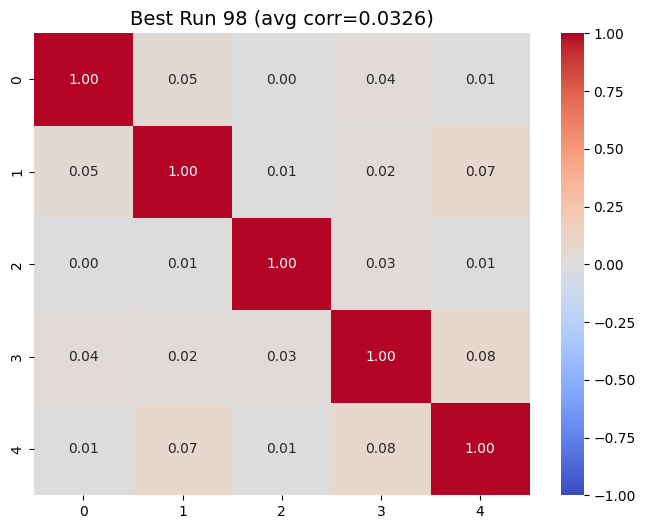

In [10]:
# Sort by lowest average correlation
sorted_results = sorted(results, key=lambda x: x["avg_abs_corr"])

print("\n=== Ranked runs by lowest avg abs correlation ===")
for r in sorted_results[:10]: 
    print(f"Run {r['run']}: avg corr={r['avg_abs_corr']:.4f}")

# Plot heatmap of the best run
best = sorted_results[0]
plt.figure(figsize=(8,6))
sns.heatmap(best["corr_matrix"], cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title(f"Best Run {best['run']} (avg corr={best['avg_abs_corr']:.4f})", fontsize=14)
plt.show()

In [8]:
all_corrs = []

for run in range(1, 101):

    # Load encoder
    encoder_path = f"saved_models/encoder_run{run}.h5"
    encoder = keras.models.load_model(
        encoder_path,
        custom_objects={"Sampling": Sampling},
        compile=False
    )

    # Encode the full validation data
    z_mean, _, _ = encoder.predict(val_data, verbose=0)
    latent_df = pd.DataFrame(z_mean, columns=[f"z{j}" for j in range(z_mean.shape[1])])
    # Correlation matrix between latent dimensions and original features
    corr_matrix = pd.concat([latent_df, df], axis=1).corr()
    latent_to_original_corr = corr_matrix.iloc[:latent_df.shape[1], latent_df.shape[1]:]

    # Store for averaging later
    all_corrs.append(latent_to_original_corr)

# --- Compute average correlation matrix across all runs ---
avg_corr = sum(all_corrs) / len(all_corrs)

# --- Plot the averaged correlation heatmap ---
vmax = np.max(np.abs(avg_corr.values))
vmin = -vmax

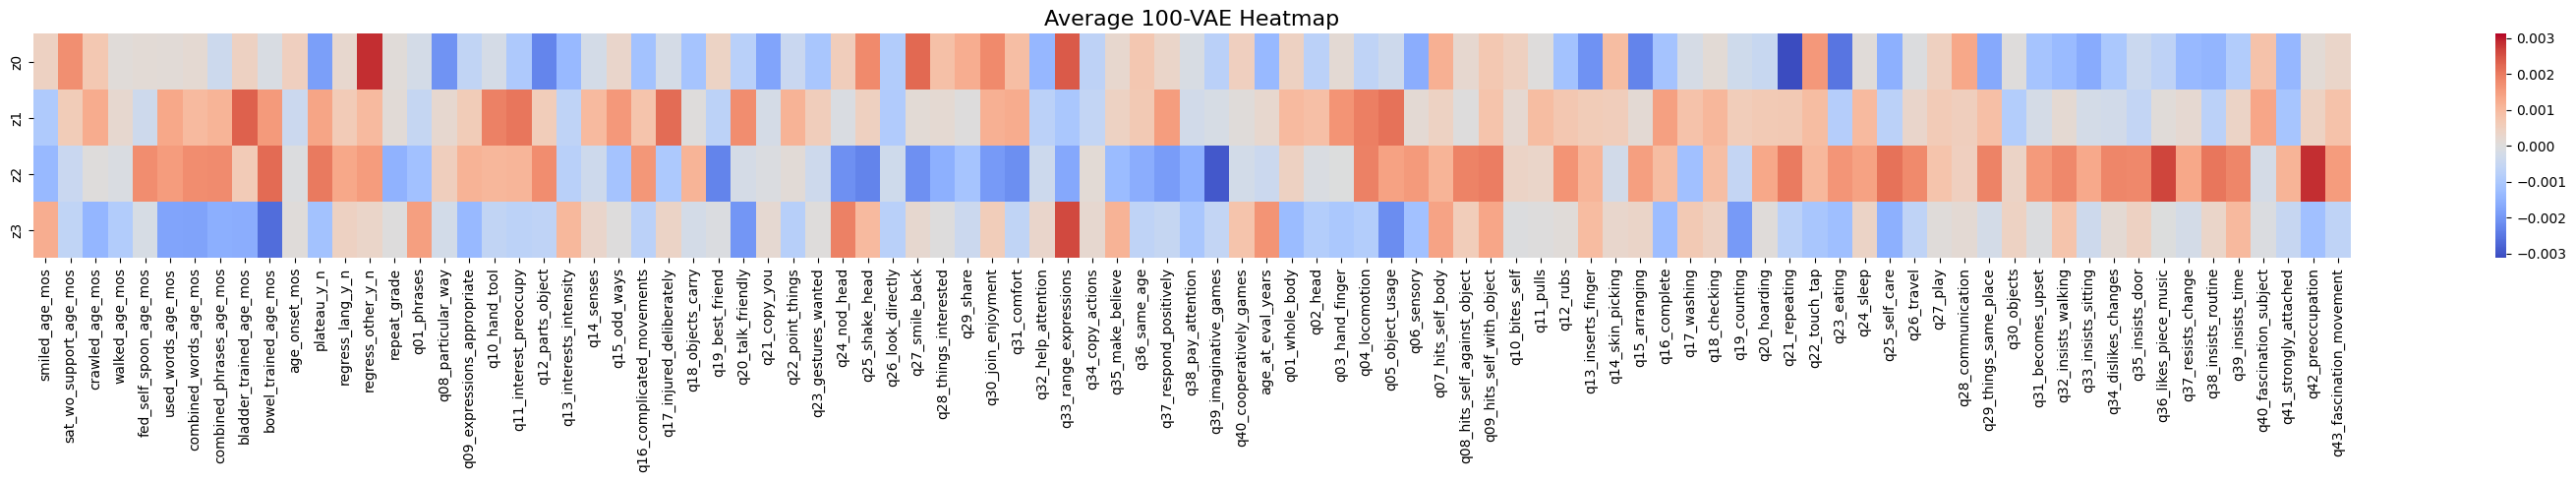

In [9]:
# --- Plot only the original heatmap ---
plt.figure(figsize=(30, 5))

sns.heatmap(avg_corr, cmap="coolwarm", vmin=vmin, vmax=vmax, cbar=True)
plt.title("Average 100-VAE Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig("original_heatmap.png", dpi=300)
plt.show()

In [13]:
print(len(all_corrs))
print(all_corrs)

100
[    smiled_age_mos  sat_wo_support_age_mos  crawled_age_mos  walked_age_mos  \
z0        0.008091                0.013566         0.005852        0.001307   
z1       -0.002561               -0.003245         0.001780        0.001654   
z2        0.000915               -0.016562        -0.002304       -0.008401   
z3        0.019352               -0.012399        -0.012980       -0.006133   

    fed_self_spoon_age_mos  used_words_age_mos  combined_words_age_mos  \
z0                0.011244           -0.003992               -0.001061   
z1                0.018725            0.008339                0.016425   
z2                0.008607           -0.009151               -0.005742   
z3                0.003321           -0.027897               -0.024043   

    combined_phrases_age_mos  bladder_trained_age_mos  bowel_trained_age_mos  \
z0                 -0.001702                -0.007516              -0.005500   
z1                  0.018494                 0.003587               

In [12]:

# Filter by absolute threshold
threshold = 0.0019
filtered_corr = avg_corr.copy()

# Keep only values where abs(corr) > threshold, set others to NaN
filtered_corr = filtered_corr.where(filtered_corr.abs() > threshold)

# Drop columns where all correlations are NaN (optional)
filtered_corr = filtered_corr.dropna(axis=1, how="all")

In [13]:
for dim in filtered_corr.index:
    significant = filtered_corr.loc[dim].dropna()
    if not significant.empty:
        print(f"\nLatent Dim {dim}:")
        print(significant.sort_values(ascending=False))



Latent Dim z0:
regress_other_y_n        0.002859
q33_range_expressions    0.002414
q27_smile_back           0.002226
q08_particular_way      -0.002055
q13_inserts_finger      -0.002096
q12_parts_object        -0.002275
q15_arranging           -0.002296
q23_eating              -0.002514
q21_repeating           -0.003123
Name: z0, dtype: float64

Latent Dim z1:
bladder_trained_age_mos     0.002340
q17_injured_deliberately    0.002185
q05_object_usage            0.002103
q11_interest_preoccupy      0.002062
q04_locomotion              0.001946
q10_hand_tool               0.001925
Name: z1, dtype: float64

Latent Dim z2:
q42_preoccupation            0.002876
q36_likes_piece_music        0.002636
bowel_trained_age_mos        0.002218
q25_self_care                0.002107
q38_insists_routine          0.002066
plateau_y_n                  0.002009
q21_repeating                0.001997
q09_hits_self_with_object    0.001971
q04_locomotion               0.001922
q37_respond_positively      -0.0

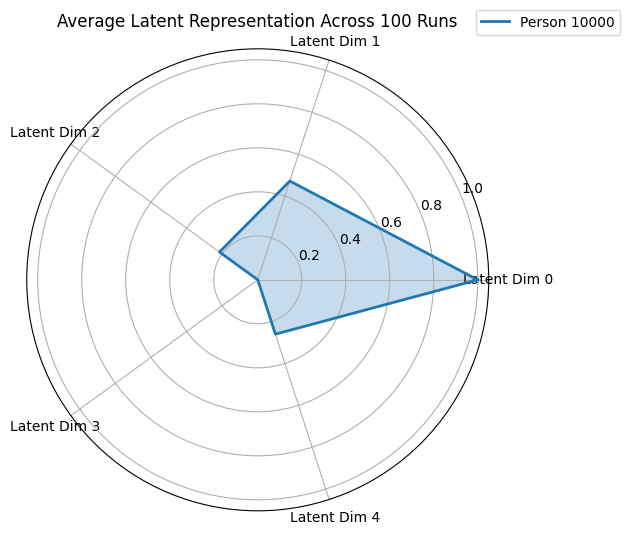

In [29]:
# Pick a person
person_index = 9999
data_point = df.iloc[person_index].values.reshape(1, -1)  # shape (1, D)

all_latents = []

# Loop through saved encoders
num_runs = 100
for run in range(num_runs):
    encoder_path = f"saved_models/encoder_run{run+1}.h5"
    encoder = load_model(
        encoder_path,
        custom_objects={"Sampling": Sampling},  # critical for VAE encoder
        compile=False
    )
    
    z_mean, _, _ = encoder.predict(data_point, verbose=0)  # shape (1, latent_dim)
    all_latents.append(z_mean[0])  # extract row

# Average across runs
avg_latent_point = np.mean(all_latents, axis=0)

# Normalize to [0,1] for radar plot
avg_latent_point = (avg_latent_point - avg_latent_point.min()) / (avg_latent_point.max() - avg_latent_point.min())

# Radar chart values
values = avg_latent_point.tolist()
values += values[:1]  # close loop

angles = np.linspace(0, 2 * np.pi, len(avg_latent_point), endpoint=False).tolist()
angles += angles[:1]

# Plot radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, label=f"Person {person_index+1}", linewidth=2, linestyle='solid')
ax.fill(angles, values, alpha=0.25)

# Labels & Styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"Latent Dim {i}" for i in range(len(avg_latent_point))])
ax.set_title("Average Latent Representation Across 100 Runs")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

Validation section 

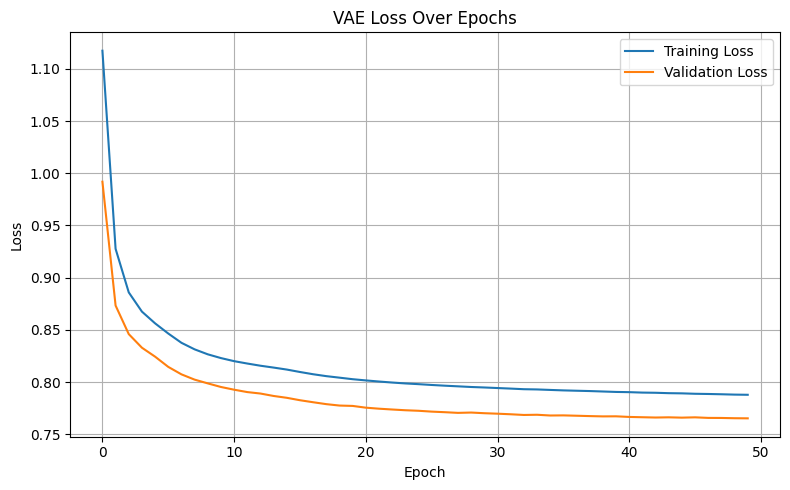

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')  # Only if val data was used
plt.title("VAE Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
from scipy.stats import pearsonr
from scipy.optimize import linear_sum_assignment

latent_dims = range(2, 13)  # latent dims
beta = 0.001
num_runs = 10
depth = 3
input_dim = train_data.shape[1]

results = []  # store validation loss
consistency_results = {}


In [18]:
import keras.backend as K
for dim in latent_dims:
    print(f"\nLatent dim={dim}, beta={beta}")
    
    latent_matrices = []
    val_losses = []

    for run in range(num_runs):
        vae, encoder, decoder = model_builder(dim, depth, beta, input_dim, summarize=False)
        vae.compile(loss="mse", optimizer=keras.optimizers.Adam())
        
        history = vae.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=30,
            verbose=0
        )
        val_losses.append(history.history['val_loss'][-1])
        
        # Encode latent mean
        z_mean, _, _ = encoder.predict(data, verbose=0)
        latent_matrices.append(z_mean)

    # Average validation loss
    results.append(np.mean(val_losses))

    # ---------------------------
    # Consistency analysis
    # ---------------------------
    Z_ref = latent_matrices[0]
    aligned_matrices = [Z_ref]

    for i in range(1, num_runs):
        Z_i = latent_matrices[i]
        K_latent = Z_ref.shape[1]
        corr_mat = np.zeros((K_latent, K_latent))

        for j in range(K_latent):
            for k in range(K_latent):
                corr, _ = pearsonr(Z_ref[:, j], Z_i[:, k])
                corr_mat[j, k] = abs(corr)

        row_ind, col_ind = linear_sum_assignment(-corr_mat)
        Z_i_aligned = Z_i[:, col_ind]

        # Flip signs if needed
        for j in range(K_latent):
            if np.corrcoef(Z_ref[:, j], Z_i_aligned[:, j])[0, 1] < 0:
                Z_i_aligned[:, j] *= -1

        aligned_matrices.append(Z_i_aligned)

    # Compute consistency scores
    consistency_scores = []
    for j in range(K_latent):
        ref_col = Z_ref[:, j]
        run_corrs = [pearsonr(ref_col, Z_i[:, j])[0] for Z_i in aligned_matrices[1:]]
        avg_corr = np.mean(run_corrs)
        std_corr = np.std(run_corrs)
        consistency_scores.append((j, avg_corr, std_corr))

    consistency_df = pd.DataFrame(consistency_scores, columns=["Latent Dim", "Avg Corr", "Std Dev"])
    consistency_results[dim] = consistency_df.sort_values(by="Avg Corr", ascending=False)


Latent dim=2, beta=0.001

Latent dim=3, beta=0.001

Latent dim=4, beta=0.001

Latent dim=5, beta=0.001

Latent dim=6, beta=0.001

Latent dim=7, beta=0.001

Latent dim=8, beta=0.001

Latent dim=9, beta=0.001

Latent dim=10, beta=0.001

Latent dim=11, beta=0.001

Latent dim=12, beta=0.001


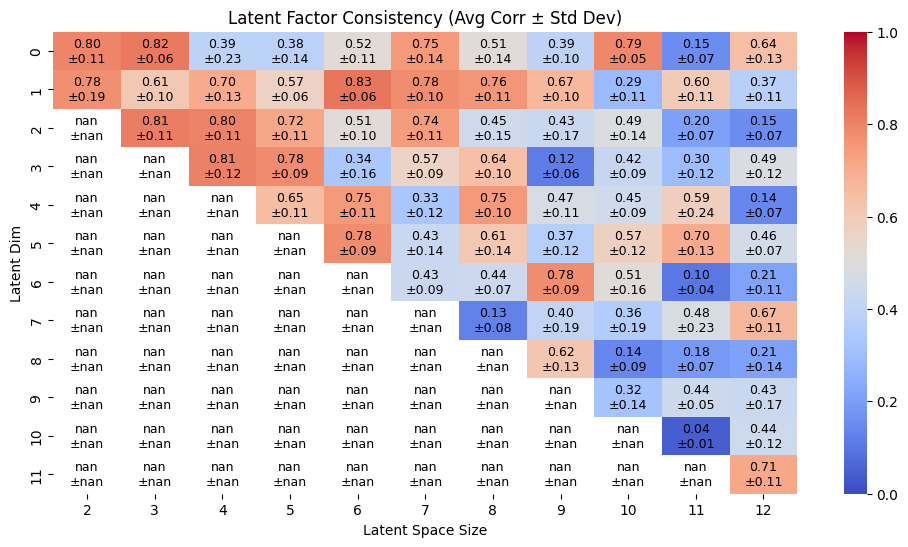

In [19]:
# ---------------------------
# Plot validation loss vs latent dims
# ---------------------------

max_dim = max(latent_dims)
avg_corr_matrix = pd.DataFrame(index=range(max_dim), columns=latent_dims, dtype=float)
std_corr_matrix = pd.DataFrame(index=range(max_dim), columns=latent_dims, dtype=float)

for dim, df in consistency_results.items():
    for _, row in df.iterrows():
        latent_idx = int(row["Latent Dim"])
        avg_corr_matrix.loc[latent_idx, dim] = row["Avg Corr"]
        std_corr_matrix.loc[latent_idx, dim] = row["Std Dev"]

plt.figure(figsize=(12, 6))
sns.heatmap(avg_corr_matrix, cmap="coolwarm", vmin=0, vmax=1, annot=False)

# Overlay both Avg Corr and Std Dev as text
for i in range(avg_corr_matrix.shape[0]):
    for j in range(avg_corr_matrix.shape[1]):
        plt.text(j+0.5, i+0.5, 
                 f"{avg_corr_matrix.iloc[i, j]:.2f}\n±{std_corr_matrix.iloc[i, j]:.2f}", 
                 ha="center", va="center", fontsize=9, color="black")

plt.title("Latent Factor Consistency (Avg Corr ± Std Dev)")
plt.xlabel("Latent Space Size")
plt.ylabel("Latent Dim")
plt.show()


In [20]:
#latent_to_original_corr.to_csv('VAE_Heatmap.csv', index=False)
#avg_corr.to_csv("avg_100_VAE_heatmap.csv", index=False)

In [21]:
print("\n=== Encoder Architecture ===")
for i, layer in enumerate(encoder.layers):
    try:
        print(f"Layer {i}: {layer.name:20s} | Output shape: {layer.output_shape}")
    except:
        pass

print("\n=== Decoder Architecture ===")
for i, layer in enumerate(decoder.layers):
    try:
        print(f"Layer {i}: {layer.name:20s} | Output shape: {layer.output_shape}")
    except:
        pass


=== Encoder Architecture ===
Layer 0: input_419            | Output shape: [(None, 93)]
Layer 1: dense_1881           | Output shape: (None, 72)
Layer 2: batch_normalization_1254 | Output shape: (None, 72)
Layer 3: dense_1882           | Output shape: (None, 52)
Layer 4: batch_normalization_1255 | Output shape: (None, 52)
Layer 5: dense_1883           | Output shape: (None, 32)
Layer 6: batch_normalization_1256 | Output shape: (None, 32)
Layer 7: dense_1884           | Output shape: (None, 12)
Layer 8: dense_1885           | Output shape: (None, 12)
Layer 9: sampling_209         | Output shape: (None, 12)

=== Decoder Architecture ===
Layer 0: input_420            | Output shape: [(None, 12)]
Layer 1: dense_1886           | Output shape: (None, 32)
Layer 2: batch_normalization_1257 | Output shape: (None, 32)
Layer 3: dense_1887           | Output shape: (None, 52)
Layer 4: batch_normalization_1258 | Output shape: (None, 52)
Layer 5: dense_1888           | Output shape: (None, 72)
Laye

In [22]:
from tensorflow.keras import backend as K

# Range of latent dimensions to test
latent_dims = list(range(2, 13))  # 2 → 12 inclusive

# Results
recon_errors = []
total_losses = []

for dim in latent_dims:
    print(f"\n===== Training VAE with latent dim = {dim} =====")

    # Build new VAE
    vae, encoder, decoder = model_builder(
        encoding_size=dim,
        depth=3,
        beta=0.001,
        input_dim=train_data.shape[1],
        summarize=False
    )

    #  Compile & Train
    vae.compile(loss="mse", optimizer=keras.optimizers.Adam())
    vae.fit(train_dataset, validation_data=val_dataset, epochs=40, verbose=0)

    #  Reconstruction loss
   # Compute reconstruction loss
    x_val = val_data if not hasattr(val_data, "values") else val_data.values
    x_recon = vae.predict(x_val, verbose=0)
    recon_loss = np.mean(np.square(x_val - x_recon))
        
    # Store results
    recon_errors.append(recon_loss)



===== Training VAE with latent dim = 2 =====

===== Training VAE with latent dim = 3 =====

===== Training VAE with latent dim = 4 =====

===== Training VAE with latent dim = 5 =====

===== Training VAE with latent dim = 6 =====

===== Training VAE with latent dim = 7 =====

===== Training VAE with latent dim = 8 =====

===== Training VAE with latent dim = 9 =====

===== Training VAE with latent dim = 10 =====

===== Training VAE with latent dim = 11 =====

===== Training VAE with latent dim = 12 =====


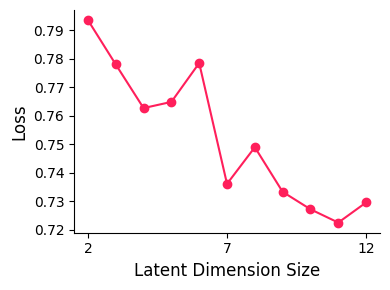

In [23]:
# ---  Plot Elbow Curve ---
plt.figure(figsize=(4, 3))
plt.plot(latent_dims, recon_errors, '-o',color="#ff1f5b")
plt.xlabel("Latent Dimension Size", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks([2,7,12])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save as SVG
plt.tight_layout()
plt.savefig("VAE_Elbow_plot.svg", format="svg", dpi=300)
plt.tight_layout()
plt.show()

Elbow point found at latent dimension = 4


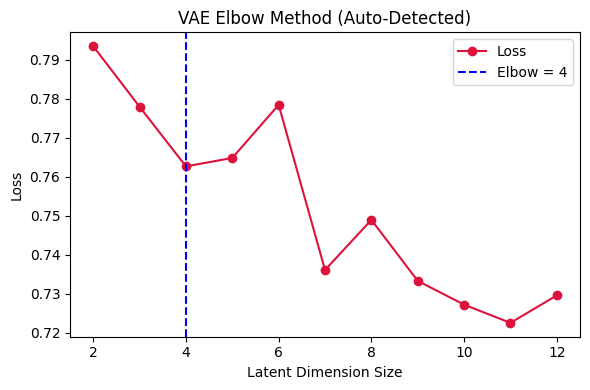

In [24]:
from kneed import KneeLocator

# --- Find the elbow ---
knee = KneeLocator(latent_dims, recon_errors, curve="convex", direction="decreasing")

print(f"Elbow point found at latent dimension = {knee.knee}")

# --- Plot the elbow ---
plt.figure(figsize=(6, 4))
plt.plot(latent_dims, recon_errors, 'o-', color='crimson', label='Loss')
if knee.knee is not None:
    plt.axvline(knee.knee, color='blue', linestyle='--', label=f'Elbow = {knee.knee}')
plt.xlabel("Latent Dimension Size")
plt.ylabel("Loss")
plt.title("VAE Elbow Method (Auto-Detected)")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

In [26]:
np.random.seed(42)

# Same 100 individuals everywhere
idx = np.random.choice(X_scaled.shape[0], size=100, replace=False)
X_raw_100 = X_scaled[idx]

raw_df = pd.DataFrame(X_raw_100)
raw_df.columns = range(raw_df.shape[1])

# -------------------------------
# Reconstruct using 100 VAEs
# -------------------------------

all_recons = []

for run in range(1, 101):
    encoder = keras.models.load_model(
        f"saved_models/encoder_run{run}.h5",
        custom_objects={"Sampling": Sampling},
        compile=False
    )
    decoder = keras.models.load_model(
        f"saved_models/decoder_run{run}.h5",
        compile=False
    )

    # Mean latent (no noise)
    z_mean, _, _ = encoder.predict(X_raw_100, verbose=0)
    X_recon = decoder.predict(z_mean, verbose=0)

    all_recons.append(X_recon)

X_recon_vae = np.mean(np.stack(all_recons, axis=0), axis=0)

recon_df = pd.DataFrame(X_recon_vae)
recon_df.columns = range(recon_df.shape[1])


ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
abs_max = np.abs(X_raw_100).max()

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
sns.heatmap(raw_df, cmap="coolwarm", vmin=-abs_max, vmax=abs_max)
plt.title("Raw Data (100 Individuals)")

plt.subplot(1, 2, 2)
sns.heatmap(recon_df, cmap="coolwarm", vmin=-abs_max, vmax=abs_max)
plt.title("VAE Average Reconstruction (100 Models)")

plt.savefig("VAE_Recon_data.svg", format="svg", dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
abs_max = np.abs(X_raw_100).max()
abs_max = 5
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
sns.heatmap(
    raw_df,
    cmap="coolwarm",
    vmin=-5,
    vmax=5
)
plt.title("Raw Data VAE (clipped to ±5)")

plt.subplot(1, 2, 2)
sns.heatmap(
    recon_df,
    cmap="coolwarm",
    vmin=-5,
    vmax=5
)
plt.title("Reconstruction VAE (clipped to ±5)")

plt.savefig("VAE_Recon_data(+-5).svg", format="svg", dpi=300)
plt.tight_layout()
plt.show()
